In [13]:
import matplotlib.pyplot as plt

In [14]:
from tensorboard.backend.event_processing import event_accumulator

In [15]:
ea1 = event_accumulator.EventAccumulator('runs/Apr09_16-55-32_Integral_p0/events.out.tfevents.1775742932.Integral.9724.0')
ea2 = event_accumulator.EventAccumulator('runs/Apr09_16-55-32_Integral_p1/events.out.tfevents.1775742932.Integral.5988.0')
ea3 = event_accumulator.EventAccumulator('runs/Apr09_16-55-32_Integral_p2/events.out.tfevents.1775742932.Integral.22380.0')
ea4 = event_accumulator.EventAccumulator('runs/Apr09_16-55-32_Integral_p3/events.out.tfevents.1775742932.Integral.22988.0')

In [16]:
ea1.Reload()
ea2.Reload()
ea3.Reload()
ea4.Reload()

In [17]:
ea1.Tags()

{'images': [],
 'audio': [],
 'histograms': [],
 'scalars': ['reward_100', 'reward'],
 'distributions': [],
 'tensors': [],
 'graph': False,
 'meta_graph': False,
 'run_metadata': []}

In [18]:
def rewards(ea: event_accumulator.EventAccumulator):
    rewards = ea.Scalars("reward")
    rtimes = [ev.wall_time for ev in rewards]
    min_time = min(rtimes)
    rtimes = [r - min_time for r in rtimes]
    rvals = [ev.value for ev in rewards]

    rewards100 = ea.Scalars("reward_100")
    r100times = [ev.wall_time for ev in rewards100]
    min_time = min(r100times)
    r100times = [r - min_time for r in r100times]
    r100vals = [ev.value for ev in rewards100]

    return (rtimes, rvals), (r100times, r100vals)

In [19]:
rewards1, rewards1001 = rewards(ea1)
rewards2, rewards1002 = rewards(ea2)
rewards3, rewards1003 = rewards(ea3)
rewards4, rewards1004 = rewards(ea4)

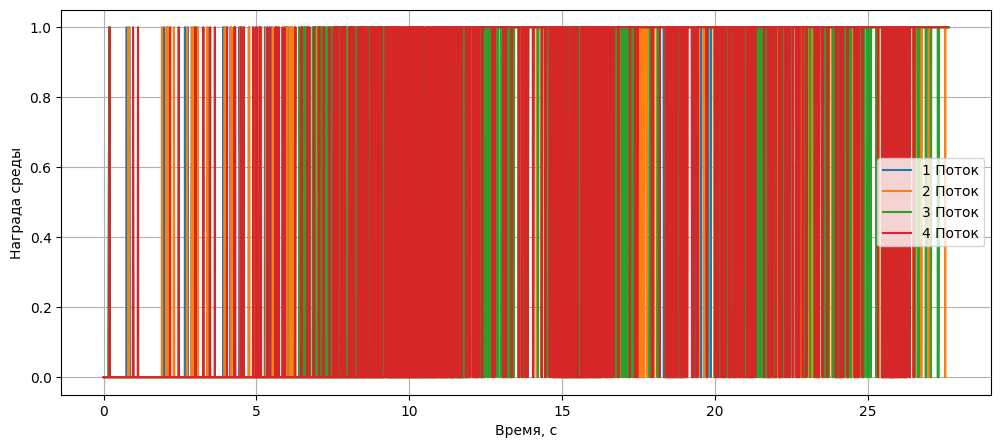

In [32]:
fig = plt.figure(figsize=(12, 5))

plt.plot(*rewards1, label="1 Поток")
plt.plot(*rewards2, label="2 Поток")
plt.plot(*rewards3, label="3 Поток")
plt.plot(*rewards4, label="4 Поток")

plt.xlabel("Время, с")
plt.ylabel("Награда среды")

plt.legend()

plt.grid()
plt.show()

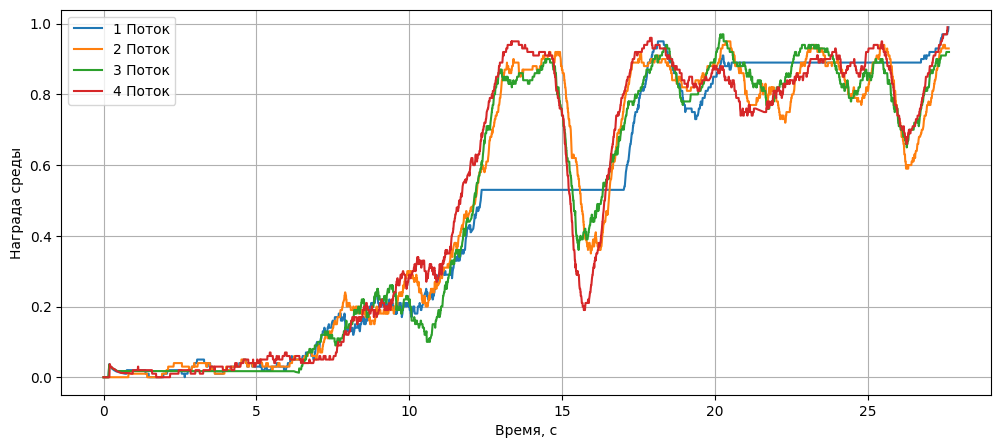

In [31]:
fig = plt.figure(figsize=(12, 5))

plt.plot(*rewards1001, label="1 Поток")
plt.plot(*rewards1002, label="2 Поток")
plt.plot(*rewards1003, label="3 Поток")
plt.plot(*rewards1004, label="4 Поток")

plt.xlabel("Время, с")
plt.ylabel("Награда среды")

plt.legend()

plt.grid()
plt.show()

In [33]:
max(rewards1[0])

27.6347713470459